In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import matplotlib.dates as mdates
import seaborn as sns

## Loading data from CSVs

In [2]:
creditdf = pd.read_csv("data/raw/credit.csv", index_col="date", parse_dates=True)
fedfundsdf = pd.read_csv("data/raw/fedfunds.csv",index_col="date", parse_dates=True)
sp500df = pd.read_csv("data/raw/sp500.csv",index_col="date", parse_dates=True)
t2ydf = pd.read_csv("data/raw/t2y.csv", index_col="date", parse_dates=True)
t10ydf = pd.read_csv("data/raw/t10y.csv", index_col="date", parse_dates=True)
vixdf = pd.read_csv("data/raw/vix.csv", index_col="date", parse_dates=True)

In [85]:
print("S&P 500:")
print(sp500df.isna().sum())
print("-----")
print("Credit:")
print(creditdf.isna().sum())
print("-----")
print("Fed-Funds:")
print(fedfundsdf.isna().sum())
print("-----")
print("Treasury 2 year:")
print(t2ydf.isna().sum())
print("-----")
print("Treasury 10 year:")
print(t10ydf.isna().sum())
print("-----")
print("VIX:")
print(vixdf.isna().sum())

S&P 500:
sp500    0
dtype: int64
-----
Credit:
credit    217
dtype: int64
-----
Fed-Funds:
fedfunds    0
dtype: int64
-----
Treasury 2 year:
t2y    213
dtype: int64
-----
Treasury 10 year:
t10y    213
dtype: int64
-----
VIX:
vix    165
dtype: int64


### Dealing with missing data
Some of the series clearly has missing data, this could be because each series comes from different sources and may follow different calendars. The sources of S&P500 and VIX usually don't report weekends/public holidays.

Fed-Funds usuallu get reported everyday, irrespective of holidays/ non-trading days.

Treasury 2 year and 10 year report data only for business days and but may skip some federal holidays that markets are open for.

In order to solve this issue, as a first step I will align the calendar to match that of the S&P 500 series.


In [3]:
trading_calendar = sp500df.index

creditdf = creditdf.reindex(trading_calendar)
fedfundsdf = fedfundsdf.reindex(trading_calendar)
t2ydf = t2ydf.reindex(trading_calendar)
t10ydf = t10ydf.reindex(trading_calendar)
vixdf = vixdf.reindex(trading_calendar)

In [70]:
print("Credit:")
print(creditdf.isna().sum())
print("-----")
print("Fed-Funds:")
print(fedfundsdf.isna().sum())
print("-----")
print("Treasury 2 year:")
print(t2ydf.isna().sum())
print("-----")
print("Treasury 10 year:")
print(t10ydf.isna().sum())
print("-----")
print("VIX:")
print(vixdf.isna().sum())

Credit:
credit    39
dtype: int64
-----
Fed-Funds:
fedfunds    0
dtype: int64
-----
Treasury 2 year:
t2y    37
dtype: int64
-----
Treasury 10 year:
t10y    37
dtype: int64
-----
VIX:
vix    0
dtype: int64


### Why are there still missing values?

In [65]:
creditdf[creditdf["credit"].isna()].head(5)

,credit
date,
2005-10-10,NaN
2005-11-11,NaN
2006-10-09,NaN
2007-10-08,NaN
2007-11-12,NaN


In [63]:
sp500df[sp500df.index == "2005-10-10"]

,sp500
date,
2005-10-10,1187.33


Credit and Treasury data still have some missing values. From above, it can be concluded that S&P 500 reports yields even on federal holidays, but that isn't the case for credit and treasury. So, it is safe to consider the yields from the previous business day. I will be imputing these missing values with the previous day's values.

In [4]:
#setting limit as 3 to account for instances that the holiday is Monday and last business day is a Friday
t10ydf = t10ydf.ffill(limit=3)
t2ydf = t2ydf.ffill(limit=3)
creditdf = creditdf.ffill(limit=3)

In [5]:
finaldf = sp500df.copy()
finaldf = finaldf.join([vixdf, t10ydf, t2ydf, fedfundsdf, creditdf])
print("Missing values after alignment and forward fill:")
print(finaldf.isna().sum())
print(f"\nDate range: {finaldf.index[0].date()} to {finaldf.index[-1].date()}")
print(f"Total trading days: {len(finaldf)}")

Missing values after alignment and forward fill:
sp500       0
vix         0
t10y        0
t2y         0
fedfunds    0
credit      0
dtype: int64

Date range: 2005-01-03 to 2024-12-31
Total trading days: 5033


## Apply stationarity transformations to all the raw data
    - sp500 : log return
    - vix : first difference
    - t2y, t10y : first difference
    - fedfunds : first difference
    - credit : first difference

Daily log returns is calculated by $$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

Here $P_t$ denotes today's closing price and $P_{t-1}$ is previous day's closing price.

In [14]:
#log return for price
df = finaldf.copy()
df["sp500_return"] = np.log(df["sp500"]).diff()
df.drop(columns = ["sp500"], inplace=True)

#first difference
for col in ["vix", "t2y", "t10y", "fedfunds", "credit"]:
    df[f"{col}_diff"] = df[col].diff()
    df.drop(columns=[col], inplace=True)

df.dropna(inplace=True)

In [15]:
print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isna().sum()}")

            sp500_return  vix_diff  t2y_diff  t10y_diff  fedfunds_diff  \
date                                                                     
2005-01-04     -0.011740     -0.10      0.10       0.06          -0.06   
2005-01-05     -0.003634      0.11      0.02       0.00           0.00   
2005-01-06      0.003500     -0.51     -0.04       0.00           0.00   
2005-01-07     -0.001432     -0.09      0.02       0.00          -0.01   
2005-01-10      0.003417     -0.26      0.03       0.00           0.02   

            credit_diff  
date                     
2005-01-04        -0.01  
2005-01-05        -0.02  
2005-01-06         0.01  
2005-01-07        -0.01  
2005-01-10        -0.01  

Shape: (5032, 6)

Columns: ['sp500_return', 'vix_diff', 't2y_diff', 't10y_diff', 'fedfunds_diff', 'credit_diff']

Missing values:
sp500_return     0
vix_diff         0
t2y_diff         0
t10y_diff        0
fedfunds_diff    0
credit_diff      0
dtype: int64


## Performing Augmented Dickey-Fuller (ADF) test

The ADF test is a check used to determine if the time series is stationary ie. its mean, variance and auto-correlation remain constant over time. I am performing this step as a preparation for when I fit the models on these series.

Usually, we consider a p-value $\textbf{less than 0.05}$ enough to reject the null hypothesis, but since I am working with log returns and first difference, I have put an even stricter check of $\textbf{less than 0.01}$.

In [16]:
def adf_test(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    return {
        "Series": name,
        "ADF Stat": round(result[0], 4),
        "p-value": round(result[1], 4),
        "Stationary": "Yes" if result[1] < 0.01 else "No"
    }

In [17]:
#Test raw stories first
raw_tests = [
    adf_test(finaldf["sp500"],    "sp500 (raw price)"),
    adf_test(finaldf["vix"],      "vix (raw)"),
    adf_test(finaldf["t10y"],     "t10y (raw)"),
    adf_test(finaldf["t2y"],      "t2y (raw)"),
    adf_test(finaldf["fedfunds"], "fedfunds (raw)"),
    adf_test(finaldf["credit"],   "credit (raw)"),
]

In [18]:
#Test transformed series
transformed_tests = [
    adf_test(df["sp500_return"], "sp500 (log return)"),
    adf_test(df["vix_diff"],     "vix (first diff)"),
    adf_test(df["t10y_diff"],    "t10y (first diff)"),
    adf_test(df["t2y_diff"],     "t2y (first diff)"),
    adf_test(df["fedfunds_diff"],"fedfunds (first diff)"),
    adf_test(df["credit_diff"],  "credit (first diff)"),
]

In [19]:
adf_results = pd.DataFrame(raw_tests + transformed_tests)
print(adf_results.to_string(index=False))

               Series  ADF Stat  p-value Stationary
    sp500 (raw price)    2.1602   0.9988         No
            vix (raw)   -5.4764   0.0000        Yes
           t10y (raw)   -1.5724   0.4974         No
            t2y (raw)   -1.1029   0.7139         No
       fedfunds (raw)   -0.9208   0.7810         No
         credit (raw)   -2.7865   0.0602         No
   sp500 (log return)  -17.2968   0.0000        Yes
     vix (first diff)  -24.4103   0.0000        Yes
    t10y (first diff)  -53.3643   0.0000        Yes
     t2y (first diff)  -10.9488   0.0000        Yes
fedfunds (first diff)   -8.4412   0.0000        Yes
  credit (first diff)  -13.7414   0.0000        Yes


The results are as expected, most of the raw series were clearly non-stationary and after the transformations it fulfills the criteria of being stationary.

## Engineer Features
I will be constructing two additional features from the existing series.
1. Realized volatility: This is the standard deviation of the S&P 500's daily log returns over the past 21 days(number of trading days in a month), annualized by $\sqrt{252}$ (number of trading days in a year).
This feature is necessary because: VIX measures what the market expects future volatily to be and realized volatility measures what volatility actually was over the past month. Feeding both of these into LSTM would let it learn what the gap is between the two.
3. Yield Curve spread (10 yr - 2yr ) serves as an macroeconomic stress signal. Under normal conditions the spread is positive, but when it is less than 0, it signals that investors expect economic slowdown or some sort of market stress. So, this feature will give the LSTM a macroeconomic context signal that just price and volatility cannot provide.

In [20]:
#21 day rolling realized volatility
df["realized_vol"] = df["sp500_return"].rolling(window=21).std()*np.sqrt(252)

#yield curve spread
df["yield_spread"] = finaldf["t10y"].reindex(df.index) - finaldf["t2y"].reindex(df.index)
df["yield_spread_diff"] = df["yield_spread"].diff()
df.drop(columns=["yield_spread"], inplace=True)

# Drop NaNs introduced by rolling window (first 21 rows)
df.dropna(inplace=True)

print(f"\nShape after feature engineering: {df.shape}")
print(f"Columns: {df.columns.tolist()}")


Shape after feature engineering: (5012, 8)
Columns: ['sp500_return', 'vix_diff', 't2y_diff', 't10y_diff', 'fedfunds_diff', 'credit_diff', 'realized_vol', 'yield_spread_diff']


## Construct Binary Regime Label

On any given day $t$, the question is: "Given what is observed today, will tomorrow be calm or turbulent?"
So the label for day $t$ needs to be tomorrow's VIX. This way, when the model sees today's features it has the correct forward-looking label to learn from.


$shift(-1)$ ensures label is strictly one day ahead, thus no lookahead leakage.

In [21]:
df["regime"] = (finaldf["vix"].reindex(df.index).shift(-1) > 20).astype(int)

#dropping last row as shift(-1) makes final row's label NaN
df.dropna(inplace=True)

print(f"Shape after label construction: {df.shape}")
print(f"\nRegime distribution:")
print(df["regime"].value_counts())
print(f"\nClass balance:")
print(df["regime"].value_counts(normalize=True).round(3))

Shape after label construction: (5012, 9)

Regime distribution:
regime
0    3342
1    1670
Name: count, dtype: int64

Class balance:
regime
0    0.667
1    0.333
Name: proportion, dtype: float64


### EDA Plots

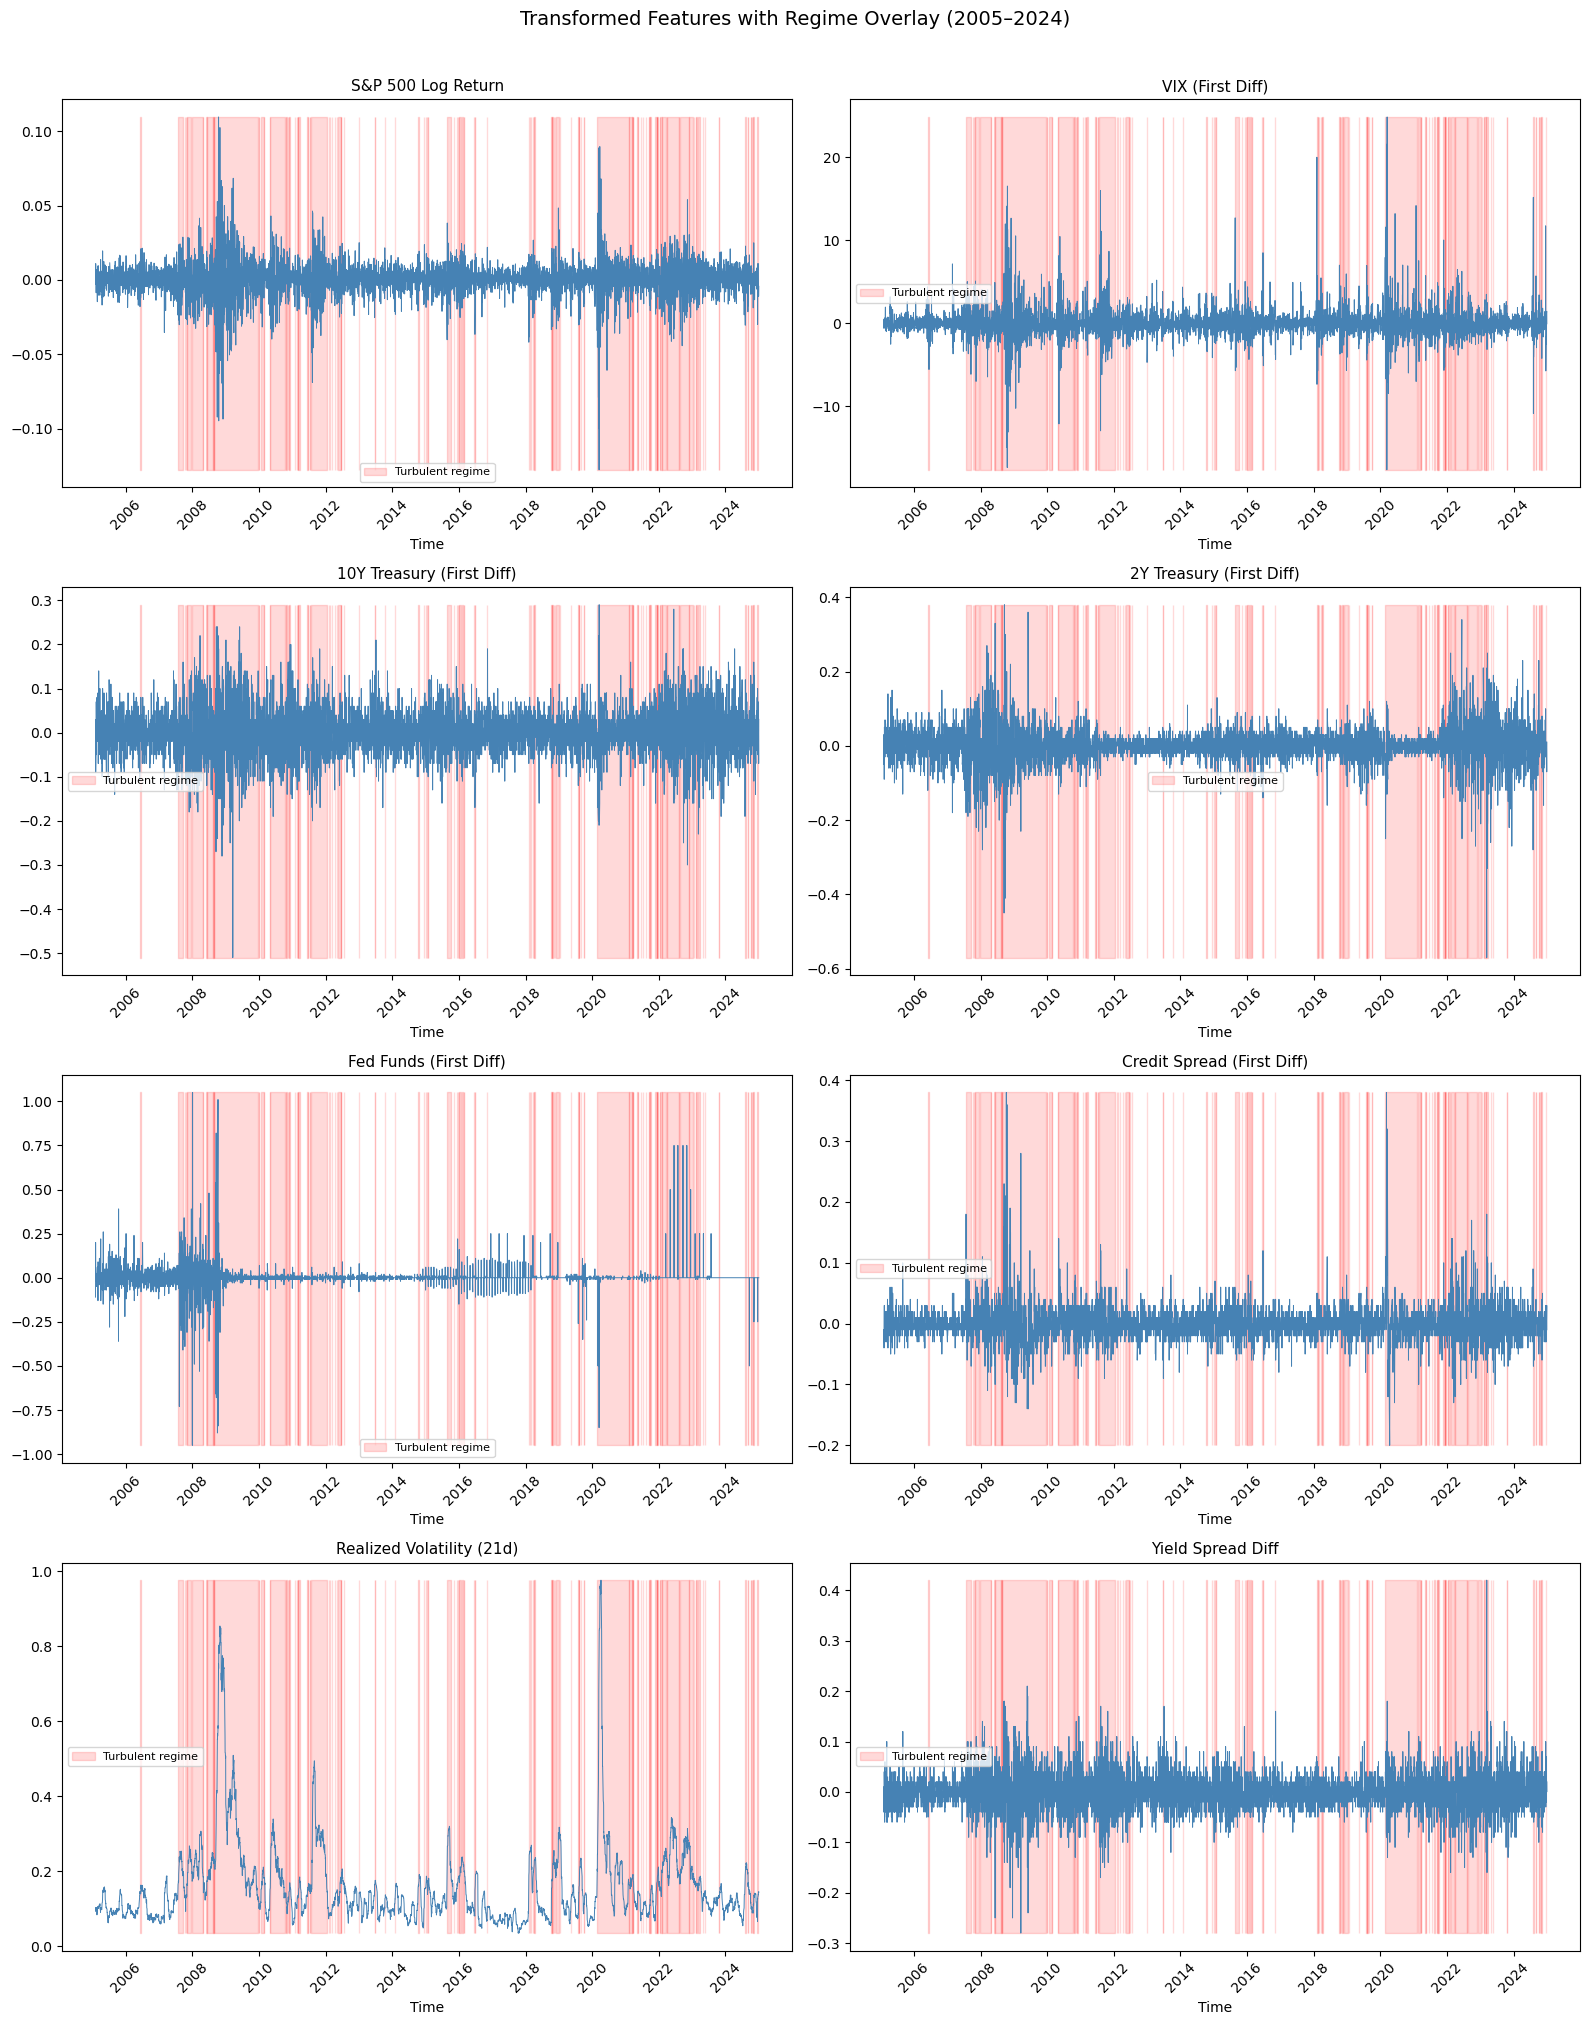

In [22]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

plot_series = {
    "S&P 500 Log Return": "sp500_return",
    "VIX (First Diff)": "vix_diff",
    "10Y Treasury (First Diff)":"t10y_diff",
    "2Y Treasury (First Diff)":"t2y_diff",
    "Fed Funds (First Diff)": "fedfunds_diff",
    "Credit Spread (First Diff)":"credit_diff",
    "Realized Volatility (21d)": "realized_vol",
    "Yield Spread Diff": "yield_spread_diff",
}

for ax, (title, col) in zip(axes, plot_series.items()):
    ax.plot(df.index, df[col], linewidth=0.7, color="steelblue")

    #shading turbulent regime periods in red
    turbulent = df["regime"] == 1
    ax.fill_between(df.index, df[col].min(), df[col].max(),
                    where=turbulent, alpha=0.15, color="red",
                    label="Turbulent regime")

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Time")
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)

plt.suptitle("Transformed Features with Regime Overlay (2005–2024)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("plots/eda_features.png", dpi=150, bbox_inches="tight")
plt.show()

The above plots show all 8 transformed features over the full 2005-2024 period, with red marking the days where the next day's VIX exceeded 20(turbulent regime).

S&P 500 log returns show the classic volatility clustering pattern: large spikes(negative and postive) concentrate within the red shaded region, particulary around 2008 and 2020. 

Fed Funds shows a different structural pattern: large rate change spikes in 2007-2008 and 2022-2023, which coincides with the turbulent regimes. This captures the Fed's crisis response.

Realized Volatility is the most informative panel here, it rises sharply and remains elevated during turbulent periods. This will be the strongest predictive feature for the LSTM model.

The yield spread difference and credit spread difference are noisier but it still highlights the stress periods.

The red shading doesn't perfectly align with the spikes for any of the panels, so no one feature can cleanly separate calm and turbulent regimes.

### VIX with regime shading

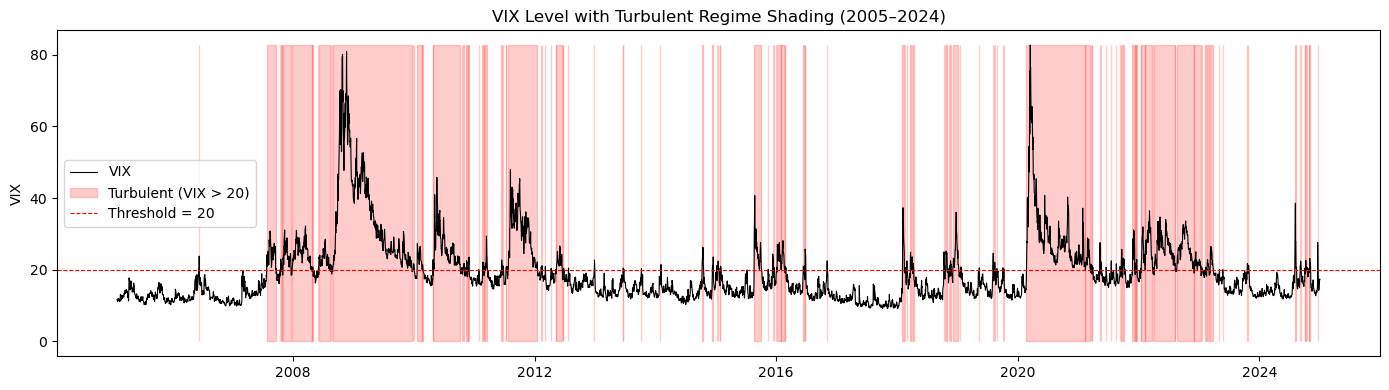

In [23]:
fig, ax = plt.subplots(figsize=(14, 4))
raw_vix = finaldf["vix"].reindex(df.index)
ax.plot(df.index, raw_vix, color="black", linewidth=0.8, label="VIX")
ax.fill_between(df.index, 0, raw_vix.max(),
                where=(df["regime"] == 1),
                alpha=0.2, color="red", label="Turbulent (VIX > 20)")
ax.axhline(20, color="red", linestyle="--", linewidth=0.8, label="Threshold = 20")
ax.set_title("VIX Level with Turbulent Regime Shading (2005–2024)")
ax.set_ylabel("VIX")
ax.legend()
plt.tight_layout()
plt.savefig("plots/vix_regimes.png", dpi=150, bbox_inches="tight")
plt.show()

The above plot shows the raw VIX level over 2005-2024 with red shading marking every day for which the next day's VIX exceeded 20.
There are 3 dominant spikes that represent market crises during the date-range: the 2008 global financial crisis, 2020 COVID crahs and 2022 rate-shock period. The 2022 rate-shock crisis is important because it is a slow turbulent regime progression, so it is harder for models to detect.

It is important to capture not just the spike peaks but also the surrounding elevated perios, so that the model predicts the regime is turbulent before the VIX spike fully materializes.

### Correlation heatmap

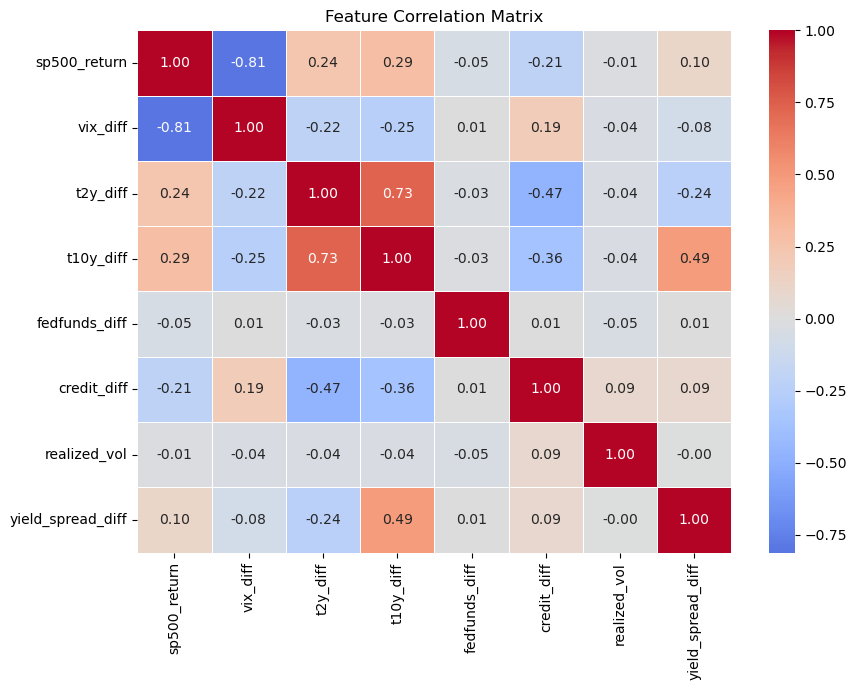

In [20]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df.drop(columns=["regime"]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("plots/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

The above heatmap showss pairwise correlations between all 8 features, ranging from -1(deep blue, perfect negative) to +1 (deep red, perfect positive).

relationships that stand out:

1. sp500_return vs vix_diff at -0.81:  when stocks fall, VIX jumps, and vice versa.
2. t2y_diff vs t10y_diff at 0.73: this is also expected, short and long-term yields tend to move together since both respond to the same macroeconomic forces, just with different magnitudes.
3. credit_diff vs t2y_diff at -0.47: when yields fall, credit spreads widen.
4. t10y_diff vs yield_spread_diff at 0.49:  since the yield spread is partially constructed from t10y.


The most important takeaway is that realized_vol is nearly uncorrelated with everything else. This means realized vol is adding genuinely independent information that the other features don't capture, making it a valuable feature for the LSTM.

### Class balance summary

In [24]:
calm      = (df["regime"] == 0).sum()
turbulent = (df["regime"] == 1).sum()
total     = len(df)

print(f"\nClass Balance Summary:")
print(f"Calm days(0): {calm:,}  ({calm/total:.1%})")
print(f"Turbulent days(1): {turbulent:,}  ({turbulent/total:.1%})")


Class Balance Summary:
Calm days(0): 3,342  (66.7%)
Turbulent days(1): 1,670  (33.3%)


In [25]:
#Save master dataframe
os.makedirs("data/processed", exist_ok=True)
df.to_csv("data/processed/master.csv")
print(f"\nMaster dataframe saved to data/processed/master.csv")
print(f"Final shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")


Master dataframe saved to data/processed/master.csv
Final shape: (5012, 9)
Columns: ['sp500_return', 'vix_diff', 't2y_diff', 't10y_diff', 'fedfunds_diff', 'credit_diff', 'realized_vol', 'yield_spread_diff', 'regime']
